In [78]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.preprocessing import LabelEncoder

In [79]:
# Importing the files

# Data consisting of the purchases of each customer for each date
transactions = pd.read_csv("data/transactions.csv")
# Detailed metadata for each article_id available for purchase
articles = pd.read_csv("data/articles.csv")
# Metadata for each customer_id in dataset
customers = pd.read_csv("data/customers.csv")

### EDA


#### Customers.csv


In [80]:
customers.head()

,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...


In [81]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1371980 entries, 0 to 1371979
Data columns (total 7 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   customer_id             1371980 non-null  object 
 1   FN                      476930 non-null   float64
 2   Active                  464404 non-null   float64
 3   club_member_status      1365918 non-null  object 
 4   fashion_news_frequency  1355969 non-null  object 
 5   age                     1356119 non-null  float64
 6   postal_code             1371980 non-null  object 
dtypes: float64(3), object(4)
memory usage: 73.3+ MB


The customers dataset contains demographic and membership-related information about users. Key columns include `customer_id`, `age`, `FN`, `Active`, `club_member_status`, and `fashion_news_frequency`.

- `customer_id` serves as a unique identifier and is used to link with transactions.
- `age` is a numerical feature but contains missing values, which were handled using median imputation. It is important for customer segmentation.
- `FN` and `Active` are binary-like features indicating engagement level; missing values were filled with 0, assuming inactivity.
- `club_member_status` and `fashion_news_frequency` are categorical features that describe customer loyalty and marketing engagement. Missing values were replaced with 'UNKNOWN' and 'NONE' respectively to preserve data.
- The `postal_code` column was removed due to its high cardinality and low usefulness for modeling.

Overall, this dataset provides valuable behavioral and demographic signals but requires careful handling of categorical encoding and missing values.


In [82]:
customers.isnull().sum().sort_values(ascending=False)

Active                    907576
FN                        895050
fashion_news_frequency     16011
age                        15861
club_member_status          6062
customer_id                    0
postal_code                    0
dtype: int64

In [83]:
customers['age'] = customers['age'].fillna(customers['age'].median())                              
customers[['FN', 'Active']] = customers[['FN', 'Active']].fillna(0)                                
customers['club_member_status'] = customers['club_member_status'].fillna('UNKNOWN')                
customers['fashion_news_frequency'] = customers['fashion_news_frequency'].fillna('NONE')
customers.drop(columns=['postal_code'], inplace=True)                                             


C:\Users\admin\AppData\Local\Temp\ipykernel_12792\3995632985.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=customers, x='Active', y='age', palette=palette)
C:\Users\admin\AppData\Local\Temp\ipykernel_12792\3995632985.py:4: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.violinplot(data=customers, x='Active', y='age', palette=palette)
C:\Users\admin\AppData\Local\Temp\ipykernel_12792\3995632985.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=customers, x='club_member_status', y='age', palette=palette)
C:\Users\admin\AppData\Local\Temp\ipykernel_12792\3995632985.py:7: UserWarning: The palette list has more values (10

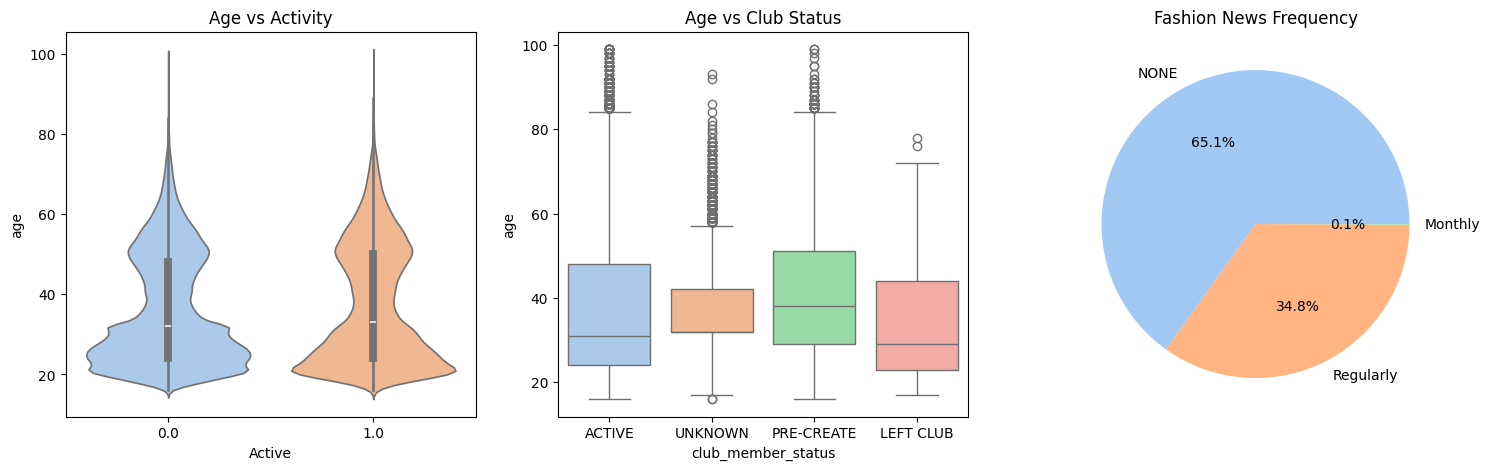

In [84]:
plt.figure(figsize=(18, 5))
palette = sns.color_palette("pastel")
plt.subplot(131).set_title('Age vs Activity')
sns.violinplot(data=customers, x='Active', y='age', palette=palette)

plt.subplot(132).set_title('Age vs Club Status')
sns.boxplot(data=customers, x='club_member_status', y='age', palette=palette)
plt.subplot(133).set_title('Fashion News Frequency')
customers['fashion_news_frequency'].value_counts().plot.pie(autopct='%1.1f%%', colors=palette, ylabel='');

#### Customer Dataset Insights

- **Age**: Missing values imputed with median value
- **FN & Active**: Binary engagement indicators filled with 0 (inactive)
- **Categorical Features**: Club status and fashion news frequency filled with 'UNKNOWN'/'NONE' to preserve information
- **Feature Removal**: Postal code dropped due to high cardinality and low predictive value

**Visual Analysis Summary:**

1. **Age vs Activity** (Violin Plot): Customer base shows a relatively balanced distribution across activities (Active=0 and Active=1), with ages concentrated in the 20-60 range, centered around 40 years.

2. **Age vs Club Status** (Box Plot): Age distributions vary slightly across membership statuses (ACTIVE, UNKNOWN, PRE-CREATE, LEFT_CLUB), with median ages around 30-40. Some outliers visible in the ACTIVE group.

3. **Fashion News Frequency** (Pie Chart): 
   - **65.1%** do not follow fashion news (NONE) - suggests low engagement with marketing communications
   - **34.8%** follow regularly (Regularly)
   - **0.1%** follow monthly (Monthly)

**Key Finding**: The dominance of non-subscribers (65%) indicates an opportunity to improve customer engagement strategies or re-evaluate the effectiveness of the fashion news channel. Age-specific loyalty programs could be designed based on observed age variations across membership statuses.

#### articles.csv

In [85]:
articles.head()

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


In [86]:
articles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   article_id                    105542 non-null  int64 
 1   product_code                  105542 non-null  int64 
 2   prod_name                     105542 non-null  object
 3   product_type_no               105542 non-null  int64 
 4   product_type_name             105542 non-null  object
 5   product_group_name            105542 non-null  object
 6   graphical_appearance_no       105542 non-null  int64 
 7   graphical_appearance_name     105542 non-null  object
 8   colour_group_code             105542 non-null  int64 
 9   colour_group_name             105542 non-null  object
 10  perceived_colour_value_id     105542 non-null  int64 
 11  perceived_colour_value_name   105542 non-null  object
 12  perceived_colour_master_id    105542 non-null  int64 
 13 

In [87]:
articles.columns

Index(['article_id', 'product_code', 'prod_name', 'product_type_no',
       'product_type_name', 'product_group_name', 'graphical_appearance_no',
       'graphical_appearance_name', 'colour_group_code', 'colour_group_name',
       'perceived_colour_value_id', 'perceived_colour_value_name',
       'perceived_colour_master_id', 'perceived_colour_master_name',
       'department_no', 'department_name', 'index_code', 'index_name',
       'index_group_no', 'index_group_name', 'section_no', 'section_name',
       'garment_group_no', 'garment_group_name', 'detail_desc'],
      dtype='object')

The `articles` dataset contains detailed metadata describing each fashion product available in the H&M recommendation system. Each row represents a unique product (`article_id`) along with hierarchical category information, visual appearance, color attributes, and textual descriptions.

| Column | Description |
|---|---|
| `article_id` | Unique identifier for each product/article. Used to connect with transaction records. |
| `product_code` | Higher-level product identifier grouping similar items together. |
| `prod_name` | Name of the product/article. |
| `product_type_no` | Numerical code representing the product type. |
| `product_type_name` | Human-readable product type (e.g., T-shirt, Dress, Trousers). |
| `product_group_name` | Broader product category grouping similar product types. |
| `graphical_appearance_no` | Numerical identifier for the graphical appearance or pattern category. |
| `graphical_appearance_name` | Descriptive name of the pattern or appearance (e.g., Solid, Stripe, Printed). |
| `colour_group_code` | Numerical code for the product color group. |
| `colour_group_name` | Name of the color group (e.g., Black, Blue, Red). |
| `perceived_colour_value_id` | Identifier representing the perceived brightness or intensity of the color. |
| `perceived_colour_value_name` | Descriptive label for color intensity (e.g., Dark, Light, Dusty). |
| `perceived_colour_master_id` | Numerical identifier for the master color category. |
| `perceived_colour_master_name` | Main perceived color category of the product. |
| `department_no` | Numerical identifier for the department category. |
| `department_name` | Department name associated with the product. |
| `index_code` | Code representing the target customer segment index. |
| `index_name` | Name of the index category. |
| `index_group_no` | Numerical identifier for the broader index group. |
| `index_group_name` | Broad customer category (e.g., Ladieswear, Menswear, Baby/Children). |
| `section_no` | Numerical identifier for the product section. |
| `section_name` | Section/category where the product belongs. |
| `garment_group_no` | Numerical identifier for garment grouping. |
| `garment_group_name` | Descriptive garment group category. |
| `detail_desc` | Detailed textual description of the product, useful for NLP or content-based recommendation systems. |

---

The articles dataset provides rich categorical and descriptive information about fashion products. Multiple hierarchical category levels (`product_group`, `index_group`, `section`, `garment_group`) help capture product relationships and customer targeting. Visual attributes such as color and graphical appearance are particularly useful for recommendation systems and customer preference analysis. However, several numerical code columns duplicate the information already available in descriptive name columns and may be removed during preprocessing to reduce redundancy.

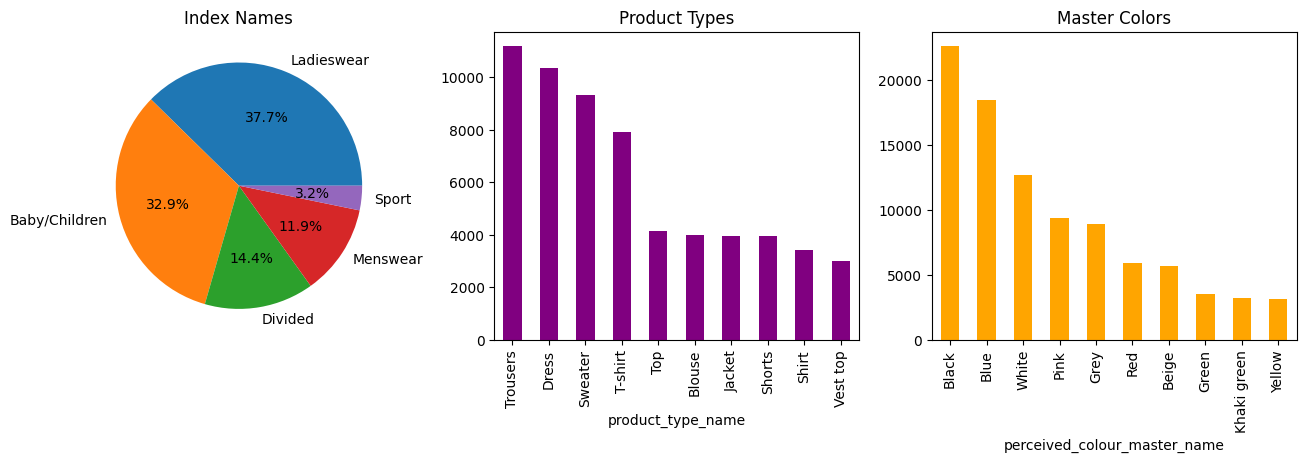

In [88]:
plt.figure(figsize=(16, 4))
plt.subplot(131).set_title('Index Names')
articles['index_group_name'].value_counts().plot.pie(autopct='%1.1f%%', ylabel='')
plt.subplot(132).set_title('Product Types')
articles['product_type_name'].value_counts().head(10).plot.bar(color='purple')
plt.subplot(133).set_title('Master Colors')
articles['perceived_colour_master_name'].value_counts().head(10).plot.bar(color='orange');

C:\Users\admin\AppData\Local\Temp\ipykernel_12792\2509442790.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_genres.values, y=top_10_genres.index, palette="mako")


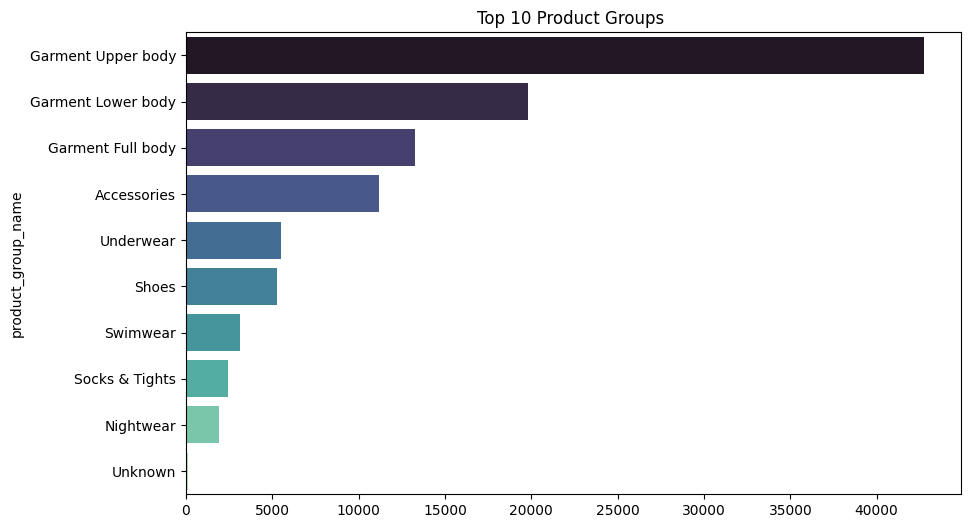

In [89]:
top_10_genres = articles.groupby('product_group_name')['product_type_name'].count().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_genres.values, y=top_10_genres.index, palette="mako")
plt.title("Top 10 Product Groups ");

C:\Users\admin\AppData\Local\Temp\ipykernel_12792\2662256435.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.index, y=data.values, palette="Set2")


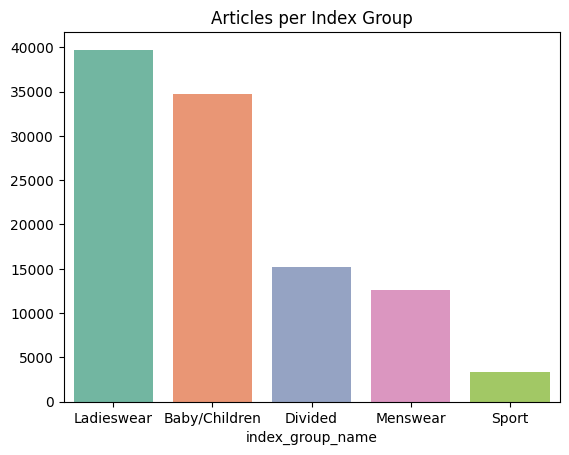

In [90]:
data = articles.groupby("index_group_name")["article_id"].nunique().sort_values(ascending=False)
sns.barplot(x=data.index, y=data.values, palette="Set2")
plt.title('Articles per Index Group');

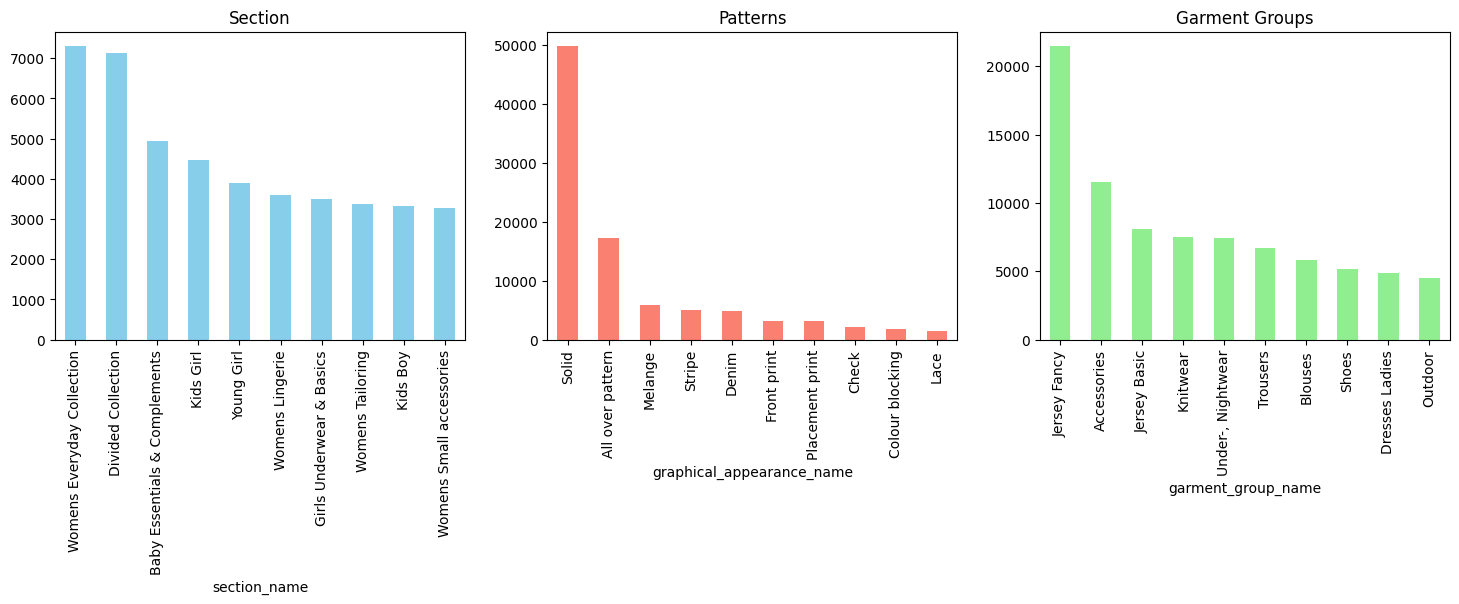

In [91]:
plt.figure(figsize=(18, 4))
plt.subplot(1, 3, 1)
articles['section_name'].value_counts().head(10).plot.bar(title='Section', color='skyblue')
plt.subplot(1, 3, 2)
articles['graphical_appearance_name'].value_counts().head(10).plot.bar(title='Patterns', color='salmon')
plt.subplot(1, 3, 3)
articles['garment_group_name'].value_counts().head(10).plot.bar(title='Garment Groups', color='lightgreen');


The visualizations reveal that the dataset is heavily dominated by upper body garments, indicating that items such as T-shirts, shirts, and tops form the core of the product catalog. There is a clear imbalance across product categories, with groups like Accessories, Shoes, and Underwear having moderate representation, while categories such as Nightwear and Socks & Tights appear significantly less frequent. In terms of index groups, Ladieswear and Baby/Children account for the majority of products, suggesting a strong business focus on these customer segments, whereas Sport remains a relatively small niche. At the section level, collections like Womens Everyday Collection and Divided Collection are the most prominent, further reinforcing the dominance of women's fashion. Additionally, the graphical appearance analysis shows that solid patterns overwhelmingly dominate the dataset, highlighting a preference for simple and minimalist designs, while more complex patterns are less common. Overall, these patterns indicate a highly skewed dataset toward women's everyday fashion, which may introduce bias in modeling and should be carefully considered in downstream tasks such as recommendation systems or predictive modeling.

C:\Users\admin\AppData\Local\Temp\ipykernel_12792\4187227293.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_depts.index, y=top_depts.values, palette="pastel")


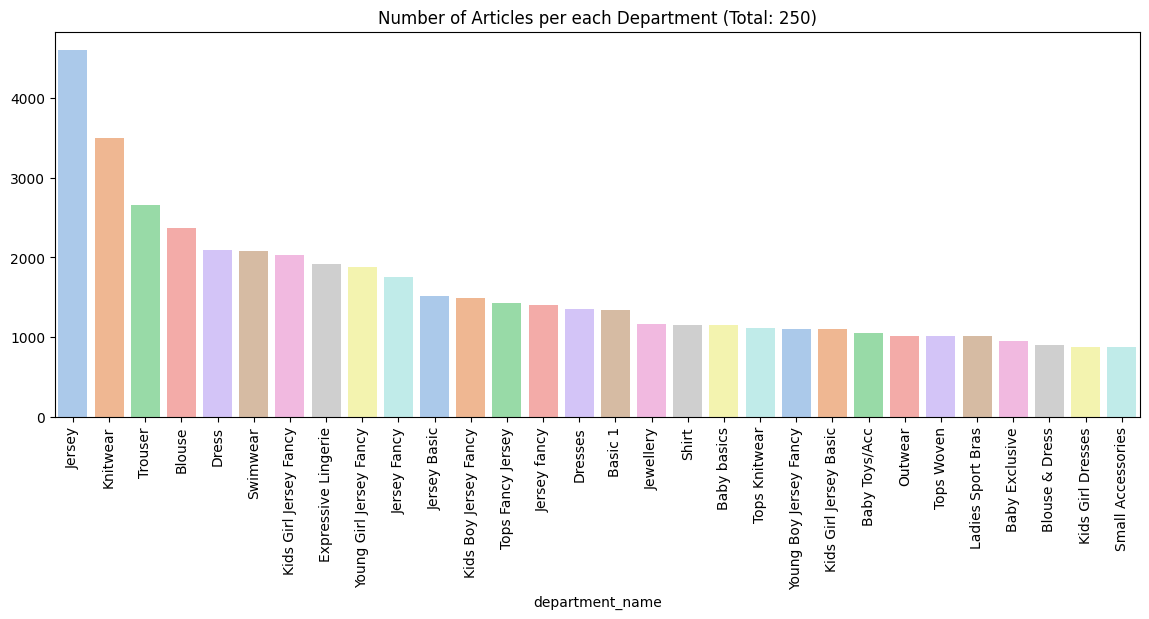

In [92]:
top_depts = articles.groupby("department_name")["article_id"].nunique().sort_values(ascending=False).head(30)
plt.figure(figsize=(14, 5))
sns.barplot(x=top_depts.index, y=top_depts.values, palette="pastel")
plt.title(f'Number of Articles per each Department (Total: {articles["department_name"].nunique()})')
plt.xticks(rotation=90);

In [93]:
articles.isnull().sum()

article_id                        0
product_code                      0
prod_name                         0
product_type_no                   0
product_type_name                 0
product_group_name                0
graphical_appearance_no           0
graphical_appearance_name         0
colour_group_code                 0
colour_group_name                 0
perceived_colour_value_id         0
perceived_colour_value_name       0
perceived_colour_master_id        0
perceived_colour_master_name      0
department_no                     0
department_name                   0
index_code                        0
index_name                        0
index_group_no                    0
index_group_name                  0
section_no                        0
section_name                      0
garment_group_no                  0
garment_group_name                0
detail_desc                     416
dtype: int64

In [94]:
# dropping the column with many null values and not much importance
drop_col = ['detail_desc']
articles.drop(columns=drop_col, inplace=True)


In [95]:
articles.head()

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_no,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear"
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear"


#### transactions.csv

In [96]:
transactions.head()

,t_dat,customer_id,article_id,price,sales_channel_id
0,2020-08-21,001c2513c498432fdff9eb09349ddf02d31826b148a8c9...,800691007,0.011847,1
1,2020-08-21,001c2513c498432fdff9eb09349ddf02d31826b148a8c9...,841182001,0.016932,1
2,2020-08-21,001c2513c498432fdff9eb09349ddf02d31826b148a8c9...,624443037,0.016932,1
3,2020-08-21,001c2513c498432fdff9eb09349ddf02d31826b148a8c9...,861600003,0.050831,1
4,2020-08-21,001c2513c498432fdff9eb09349ddf02d31826b148a8c9...,815579001,0.030492,1


In [97]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1224824 entries, 0 to 1224823
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   t_dat             1224824 non-null  object 
 1   customer_id       1224824 non-null  object 
 2   article_id        1224824 non-null  int64  
 3   price             1224824 non-null  float64
 4   sales_channel_id  1224824 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 46.7+ MB


In [98]:
transactions.isnull().sum()

t_dat               0
customer_id         0
article_id          0
price               0
sales_channel_id    0
dtype: int64

The transactions dataset captures user purchase behavior over time. It includes `t_dat`, `customer_id`, `article_id`,`sales_channel_id` and `price`.

- `t_dat` is a timestamp column that enables time-based analysis such as seasonality, recency, and trend detection.
- `customer_id` and `article_id` are foreign keys linking to customers and articles datasets.
- `price` is a numerical feature representing the transaction value, scaled down by a factor of 1000. It can be transformed back to the original value (in SEK) if needed.
- This dataset is the core of the system, enabling analysis of purchasing patterns and user-item interactions.

Overall, the transactions data is critical for building recommendation systems, especially collaborative filtering and sequential models.

In [99]:
transactions['price_original(SEK)'] = transactions['price'] * 1000

In [102]:
transactions.head()

,t_dat,customer_id,article_id,price,sales_channel_id,price_original(SEK)
0,2020-08-21,001c2513c498432fdff9eb09349ddf02d31826b148a8c9...,800691007,0.011847,1,11.847458
1,2020-08-21,001c2513c498432fdff9eb09349ddf02d31826b148a8c9...,841182001,0.016932,1,16.932203
2,2020-08-21,001c2513c498432fdff9eb09349ddf02d31826b148a8c9...,624443037,0.016932,1,16.932203
3,2020-08-21,001c2513c498432fdff9eb09349ddf02d31826b148a8c9...,861600003,0.050831,1,50.830508
4,2020-08-21,001c2513c498432fdff9eb09349ddf02d31826b148a8c9...,815579001,0.030492,1,30.491525


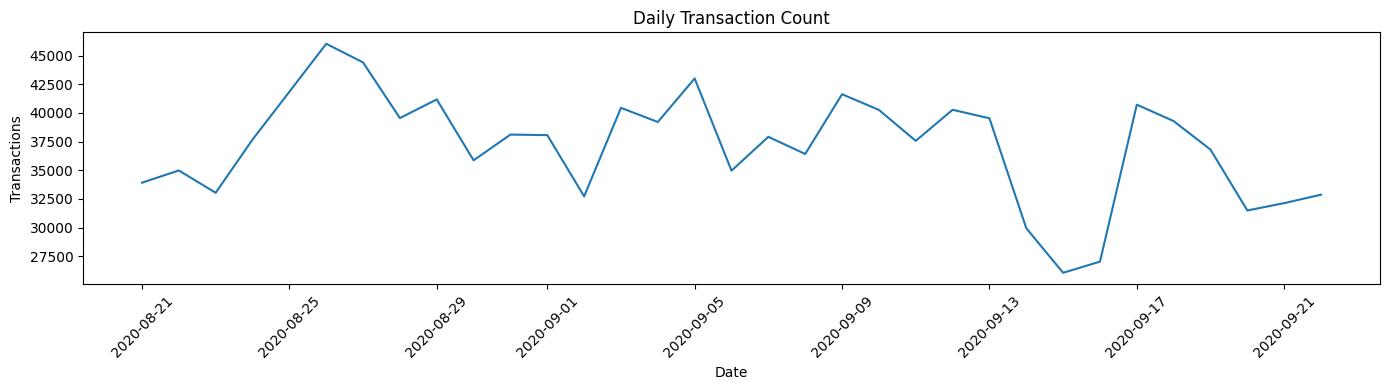

In [103]:
 # Basic time series of daily transaction count
daily_counts = transactions.groupby('t_dat').size().reset_index(name='count')
plt.figure(figsize=(14, 4))
sns.lineplot(data=daily_counts, x='t_dat', y='count')
plt.title('Daily Transaction Count')
plt.xlabel('Date')
plt.ylabel('Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

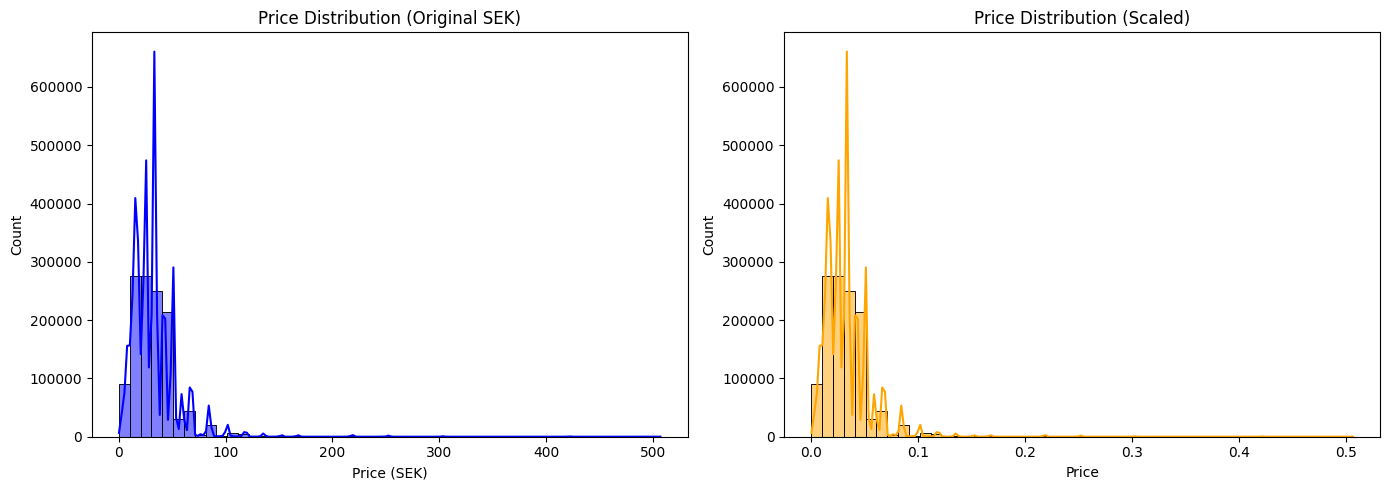

In [110]:
# Price distribution
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(transactions['price_original(SEK)'], bins=50, kde=True, color='blue')
plt.title('Price Distribution (Original SEK)')
plt.xlabel('Price (SEK)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(transactions['price'], bins=50, kde=True, color='orange')
plt.title('Price Distribution (Scaled)')
plt.xlabel('Price')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

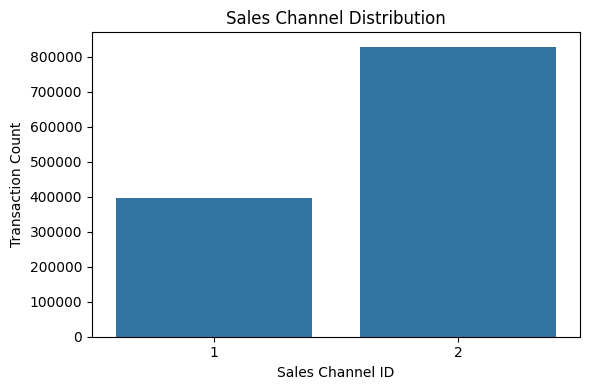

In [105]:
# Sales channel distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=transactions, x='sales_channel_id')
plt.title('Sales Channel Distribution')
plt.xlabel('Sales Channel ID')
plt.ylabel('Transaction Count')
plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_12792\4105229570.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_items.values, y=top_items.index.astype(str), palette='viridis')


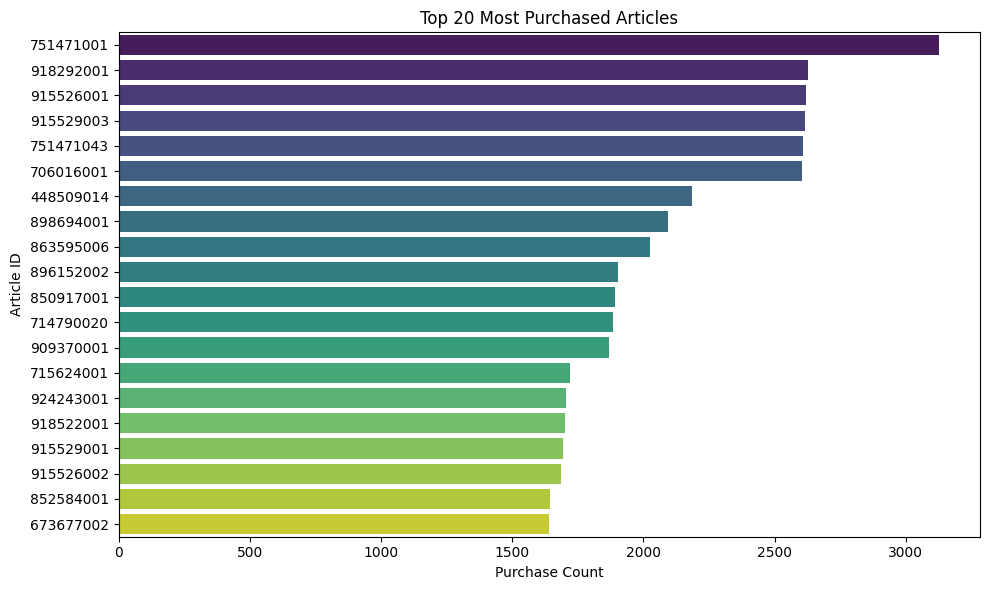

In [106]:
# Top 20 articles by purchase count
top_items = transactions['article_id'].value_counts().head(20)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_items.values, y=top_items.index.astype(str), palette='viridis')
plt.title('Top 20 Most Purchased Articles')
plt.xlabel('Purchase Count')
plt.ylabel('Article ID')
plt.tight_layout()
plt.show()

### preprocessing

In [ ]:

# Date conversion
if 't_dat' in transactions.columns:
    transactions['t_dat'] = pd.to_datetime(transactions['t_dat'], errors='coerce')

# Numeric conversion
if 'price' in transactions.columns:
    transactions['price'] = pd.to_numeric(transactions['price'], errors='coerce')
    
if 'age' in customers.columns:
    customers['age'] = pd.to_numeric(customers['age'], errors='coerce')

for col in ['FN', 'Active']:
    if col in customers.columns:
        customers[col] = pd.to_numeric(customers[col], errors='coerce').fillna(0).astype(int)

# Categorical conversion
customer_cat_cols = ['club_member_status', 'fashion_news_frequency']
article_cat_cols = [
    'product_type_name', 'article_type_name', 'colour_group_name',
    'garment_group_name', 'perceived_colour_master_name'
]
for col in customer_cat_cols:
    if col in customers.columns:
        customers[col] = customers[col].astype('category')
for col in article_cat_cols:
    if col in articles.columns:
        articles[col] = articles[col].astype('category')

print('Transaction dtypes:')
print(transactions[['t_dat', 'price']].dtypes)
print('\nCustomer dtypes:')
print(customers[customers.columns.intersection(customer_cat_cols + ['age', 'FN', 'Active'])].dtypes)
print('\nArticle categorical dtypes:')
print(articles[articles.columns.intersection(article_cat_cols)].dtypes)

Transaction dtypes:
t_dat    datetime64[ns]
price           float64
dtype: object

Customer dtypes:
FN                           int64
Active                       int64
club_member_status        category
fashion_news_frequency    category
age                        float64
dtype: object

Article categorical dtypes:
product_type_name               category
colour_group_name               category
perceived_colour_master_name    category
garment_group_name              category
dtype: object


In [115]:
if 'price_original(SEK)' in transactions.columns:
    q1 = transactions['price_original(SEK)'].quantile(0.25)
    q3 = transactions['price_original(SEK)'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    initial_count = len(transactions)
    transactions = transactions[(transactions['price_original(SEK)'] >= lower_bound) & (transactions['price_original(SEK)'] <= upper_bound)]
    removed_count = initial_count - len(transactions)
    print('Removed outliers:', removed_count)
    print('Remaining transactions:', len(transactions))
else:
    print('Column price_original(SEK) not found in transactions.')

transactions.head()

Removed outliers: 39398
Remaining transactions: 1185426


,t_dat,customer_id,article_id,price,sales_channel_id,price_original(SEK),month,price_clipped,price_log
0,2020-08-21,001c2513c498432fdff9eb09349ddf02d31826b148a8c9...,800691007,0.011847,1,11.847458,2020-08,0.011847,0.011778
1,2020-08-21,001c2513c498432fdff9eb09349ddf02d31826b148a8c9...,841182001,0.016932,1,16.932203,2020-08,0.016932,0.016790
2,2020-08-21,001c2513c498432fdff9eb09349ddf02d31826b148a8c9...,624443037,0.016932,1,16.932203,2020-08,0.016932,0.016790
3,2020-08-21,001c2513c498432fdff9eb09349ddf02d31826b148a8c9...,861600003,0.050831,1,50.830508,2020-08,0.050831,0.049581
4,2020-08-21,001c2513c498432fdff9eb09349ddf02d31826b148a8c9...,815579001,0.030492,1,30.491525,2020-08,0.030492,0.030036


In [116]:
articles.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype   
---  ------                        --------------   -----   
 0   article_id                    105542 non-null  int64   
 1   product_code                  105542 non-null  int64   
 2   prod_name                     105542 non-null  object  
 3   product_type_no               105542 non-null  int64   
 4   product_type_name             105542 non-null  category
 5   product_group_name            105542 non-null  object  
 6   graphical_appearance_no       105542 non-null  int64   
 7   graphical_appearance_name     105542 non-null  object  
 8   colour_group_code             105542 non-null  int64   
 9   colour_group_name             105542 non-null  category
 10  perceived_colour_value_id     105542 non-null  int64   
 11  perceived_colour_value_name   105542 non-null  object  
 12  perceived_colour_master_id    

In [ ]:
from sklearn.preprocessing import LabelEncoder

# ===== CUSTOMERS =====
# One-hot encode low-cardinality categorical features
customers_ohe = pd.get_dummies(customers[['club_member_status', 'fashion_news_frequency']], 
                                prefix=['club', 'fashion'], drop_first=False)
customers = pd.concat([customers.drop(columns=['club_member_status', 'fashion_news_frequency']), customers_ohe], axis=1)
print('Customers after encoding:')
print(customers.head())
print('Customers shape:', customers.shape)
print('Customers columns:', customers.columns.tolist())

# ===== ARTICLES =====
# One-hot encode low-cardinality features (direct one-hot)
ohe_cols = ['product_type_name', 'colour_group_name', 'graphical_appearance_name', 'perceived_colour_value_name']
ohe_cols = [col for col in ohe_cols if col in articles.columns]
if ohe_cols:
    articles_ohe = pd.get_dummies(articles[ohe_cols], prefix=ohe_cols, drop_first=False)
    articles = pd.concat([articles.drop(columns=ohe_cols), articles_ohe], axis=1)

# Label encode high-cardinality categorical features
label_cols = ['article_type_name', 'perceived_colour_master_name', 'garment_group_name', 
              'product_group_name', 'index_group_name', 'section_name', 'department_name']
label_cols = [col for col in label_cols if col in articles.columns]
label_encoders = {}
for col in label_cols:
    le = LabelEncoder()
    articles[col + '_encoded'] = le.fit_transform(articles[col].fillna('Unknown').astype(str))
    label_encoders[col] = le
    articles.drop(columns=[col], inplace=True)

print('\nArticles after encoding:')
print(articles.head())
print('Articles shape:', articles.shape)
print('Articles columns:', articles.columns.tolist())

# ===== TRANSACTIONS =====
# One-hot encode sales_channel_id
if 'sales_channel_id' in transactions.columns:
    trans_ohe = pd.get_dummies(transactions[['sales_channel_id']], prefix='channel', drop_first=False)
    transactions = pd.concat([transactions.drop(columns=['sales_channel_id']), trans_ohe], axis=1)

print('\nTransactions after encoding:')
print(transactions.head())
print('Transactions shape:', transactions.shape)
print('Transactions columns:', transactions.columns.tolist())
print('\nEncoding complete!')

### Encode Remaining Categorical Columns
Auto-detect and encode any remaining object/categorical dtype columns that may have been missed in the manual pipeline.

In [ ]:
# Auto-detect and encode remaining categorical columns with object dtype

# CUSTOMERS - remaining object columns
customer_remaining = customers.select_dtypes(include=['object']).columns.tolist()
if customer_remaining:
    print('Remaining categorical columns in customers:', customer_remaining)
    for col in customer_remaining:
        le = LabelEncoder()
        customers[col + '_encoded'] = le.fit_transform(customers[col].fillna('Unknown').astype(str))
        customers.drop(columns=[col], inplace=True)

# ARTICLES - remaining object columns
article_remaining = articles.select_dtypes(include=['object']).columns.tolist()
if article_remaining:
    print('Remaining categorical columns in articles:', article_remaining)
    for col in article_remaining:
        le = LabelEncoder()
        articles[col + '_encoded'] = le.fit_transform(articles[col].fillna('Unknown').astype(str))
        articles.drop(columns=[col], inplace=True)

# TRANSACTIONS - remaining object columns
trans_remaining = transactions.select_dtypes(include=['object']).columns.tolist()
if trans_remaining:
    print('Remaining categorical columns in transactions:', trans_remaining)
    for col in trans_remaining:
        le = LabelEncoder()
        transactions[col + '_encoded'] = le.fit_transform(transactions[col].fillna('Unknown').astype(str))
        transactions.drop(columns=[col], inplace=True)

print('\n=== Final Dataset Shapes ===')
print('Customers:', customers.shape)
print('Articles:', articles.shape)
print('Transactions:', transactions.shape)
print('\nAll categorical columns have been encoded!')